Actual: ['Yes' 'No']
Predicted: ['Yes' 'No']
Accuracy: 1.0
New Employee Promotion: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


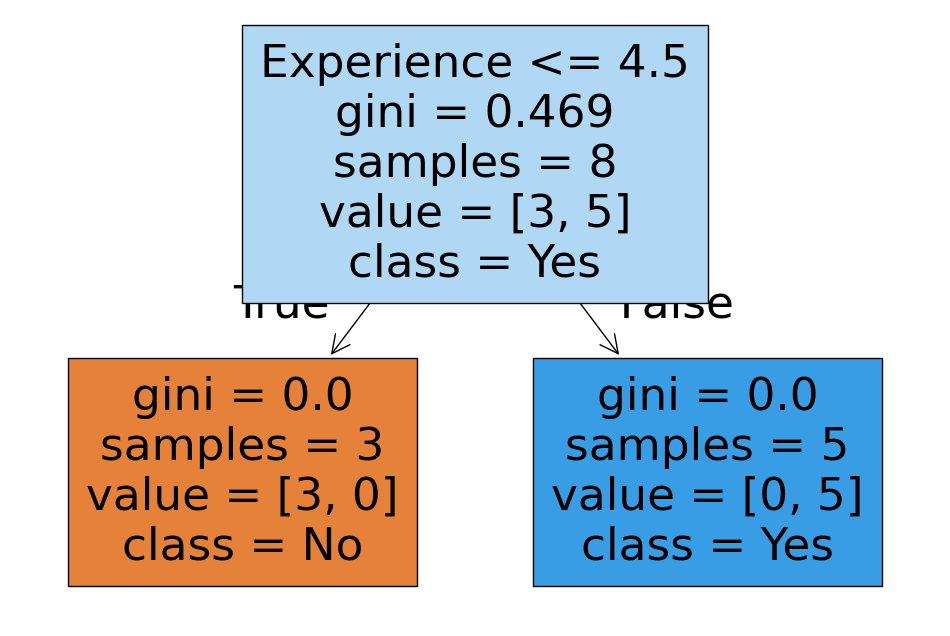

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

data = {
    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Performance": [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
    "Promotion": ["No", "No", "No", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"]
}
df = pd.DataFrame(data)
X = df[["Experience", "Performance"]]
y = df["Promotion"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Actual:", y_test.values)
print("Predicted:", y_pred)
print("Accuracy:", accuracy)

new_employee = [[5, 72]]
prediction = model.predict(new_employee)
print("New Employee Promotion:", prediction[0])
plt.figure(figsize=(12, 8))
plot_tree(model,feature_names=["Experience", "Performance"],class_names=model.classes_,
    filled=True)
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
x= np.array([[1],[2],[3],[4],[5],[6],[7],[8],[19],[10],[11],[12]])
y=np.array([0,0,0,0,0,1,1,1,1,1,1,1])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25)
print("Training samples:",len(X_train))
for k in [1,3,5,7,9]:
   model=KNeighborsClassifier(n_neighbors=k)
   model.fit(X_train, y_train)
   accuracy=model.score(X_test,y_test)
   print(f"k={k},Accuracy={accuracy:.2f}")

Training samples: 9
k=1,Accuracy=0.67
k=3,Accuracy=0.67
k=5,Accuracy=0.33
k=7,Accuracy=0.33
k=9,Accuracy=0.00


In [ ]:
#Ensamble learning
import pandas as pd

data = {
    "StudyHours": [1, 2, 3, 4, 5],
    "Attendance": [50, 55, 60, 65, 70],
    "PreviousMarks": [35, 40, 45, 50, 55],
    "Result": ["Fail", "Fail", "Fail", "Fail", "Pass"]
}
df = pd.DataFrame(data)
x=df[["StudyHours","Attendance","PreviousMarks"]]
y=df["Result"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
df



,StudyHours,Attendance,PreviousMarks,Result
0,1,50,35,Fail
1,2,55,40,Fail
2,3,60,45,Fail
3,4,65,50,Fail
4,5,70,55,Pass


In [ ]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
rf_accuracy=accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:",rf_accuracy)

Random Forest Accuracy: 1.0


In [ ]:
#dt accuracy
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)
dt_accuracy=accuracy_score(y_test,dt_pred)
print("Decision Tree Accuracy:",dt_accuracy)


Decision Tree Accuracy: 1.0


In [ ]:
#gb accuracy
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train,y_train)
gb_pred=gb.predict(x_test)
gb_accuracy=accuracy_score(y_test,gb_pred)
print("Gradient Boosting Accuracy:",gb_accuracy)

Gradient Boosting Accuracy: 1.0


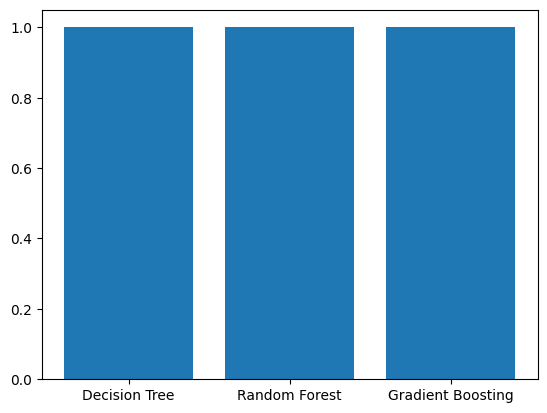

Prediction: ['Pass']


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt
models=["Decision Tree","Random Forest","Gradient Boosting"]
scores=[dt_accuracy,rf_accuracy,gb_accuracy]
plt.bar(models, scores)
plt.show()

#Suppose a new student has:
#new data

new_student=[[6,82,68]]
prediction = rf.predict(new_student)
print("Prediction:",prediction)

   Age  Spending  clusters
0   20      2000         0
1   22      2500         0
2   21      2200         0
3   23      2700         0
4   40      7000         1
5   42      7500         1
6   45      8000         1
7   43      7200         1

Centroids:
[[  21.5 2350. ]
 [  42.5 7425. ]]


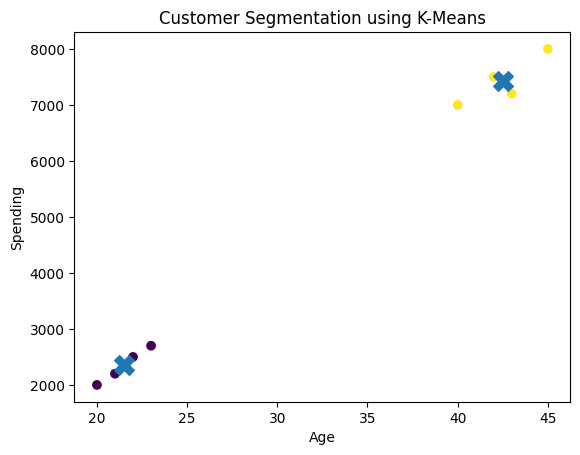

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
data={
    "Age":[20,22,21,23,40,42,45,43],
    "Spending":[2000,2500,2200,2700,7000,7500,8000,7200]
}
df=pd.DataFrame(data)
x=df[["Age","Spending"]]
model =KMeans(n_clusters=2,random_state=42,n_init=10)

model.fit(x)

df["clusters"]=model.labels_
print(df)
centers=model.cluster_centers_
print("\nCentroids:")
print(centers)
plt.scatter(df["Age"],df["Spending"],c=df["clusters"])
plt.scatter(centers[:,0],centers[:,1],marker="X",s=200)
plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer Segmentation using K-Means")
plt.show()


   Age  Spending  Cluster
0   20      2000        0
1   22      2500        0
2   21      2200        0
3   23      2700        0
4   40      7000        1
5   42      7500        1
6   45      8000        1
7   43      7200        1


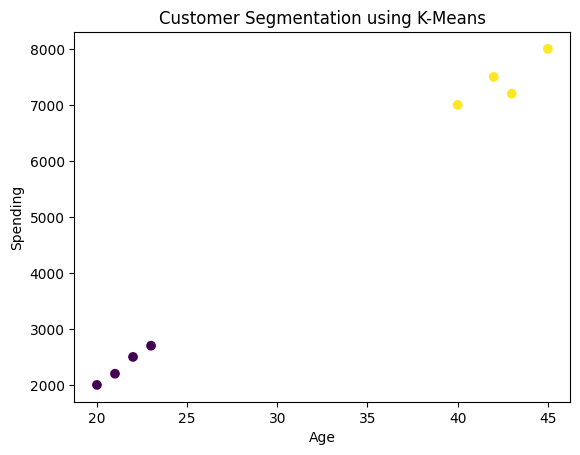

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

data = {
    "Age": [20, 22, 21, 23, 40, 42, 45, 43],
    "Spending": [2000, 2500, 2200, 2700, 7000, 7500, 8000, 7200]
}

df = pd.DataFrame(data)

X = df[["Age", "Spending"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

model.fit(X_scaled)

df["Cluster"] = model.labels_

print(df)

plt.scatter(
    df["Age"],
    df["Spending"],
    c=df["Cluster"]
)

plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer Segmentation using K-Means")
plt.show()